IMPORT LIBRARIES

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from xgboost import XGBClassifier

LOAD DATASETS

In [85]:
train_df = pd.read_csv(
    "customer_churn_dataset-training-master.csv"
)

test_df = pd.read_csv(
    "customer_churn_dataset-testing-master.csv"
)

COMBINE DATASETS

In [86]:
df = pd.concat(
    [train_df, test_df],
    ignore_index=True
)

SHUFFLE DATASET

In [87]:
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

REMOVE MISSING TARGET VALUES

In [88]:
df = df.dropna(subset=["Churn"])

REMOVE CUSTOMER ID

In [89]:
df.drop("CustomerID", axis=1, inplace=True)

HANDLE MISSING VALUES

In [90]:
# ============================================================
# HANDLE MISSING VALUES
# ============================================================

print("\nMISSING VALUES\n")
print(df.isnull().sum())

df.dropna(inplace=True)


MISSING VALUES

Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64


ONE-HOT ENCODING
Converts categorical text columns into numerical columns.

In [91]:
# ============================================================
# ONE HOT ENCODING
# ============================================================

df = pd.get_dummies(
    df,
    columns=[
        "Gender",
        "Subscription Type",
        "Contract Length"
    ],
    drop_first=True
)

FEATURE ENGINEERING

Creates new meaningful features from existing data.

Engineered features help the model learn hidden customer behavior patterns.

Avg Monthly Spend: Average spending per month.

Engagement Score: Measures customer activity level.

Customer Value Score: Represents overall customer importance.

Inactivity Score: Measures customer inactivity risk.

Feature engineering often improves prediction accuracy significantly.

In [92]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================

df["Avg Monthly Spend"] = (
    df["Total Spend"] / (df["Tenure"] + 1)
)

df["Engagement Score"] = (
    df["Usage Frequency"] /
    (df["Last Interaction"] + 1)
)

df["Customer Value Score"] = (
    df["Total Spend"] *
    df["Usage Frequency"]
)

df["Inactivity Score"] = (
    df["Last Interaction"] /
    (df["Usage Frequency"] + 1)
)

FEATURES & TARGET

In [93]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

TRAIN TEST SPLIT

In [94]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(404164, 16)
(101042, 16)
Churn
1.0    0.555203
0.0    0.444797
Name: proportion, dtype: float64
Churn
1.0    0.555205
0.0    0.444795
Name: proportion, dtype: float64


BUILD XGBOOST MODEL

n_estimators

Number of decision trees.

learning_rate

Controls learning speed.

max_depth

Maximum tree depth.

subsample

Uses random sample of rows.

colsample_bytree

Uses random sample of columns.

These settings reduce overfitting and improve performance.

In [95]:
model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

TRAIN MODEL

In [96]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

MAKE PREDICTIONS

In [97]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

MODEL EVALUATION METRICS

Accuracy: Overall correctness.

Precision: How many predicted churners are actual churners.

Recall: How many actual churners are detected.

F1-score: Balance between precision and recall.

Confusion Matrix Shows:

true positives, true negatives, false positives, false negatives

In [98]:
# ============================================================
# MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nMODEL ACCURACY")
print(accuracy)

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))

print("\nCONFUSION MATRIX")
print(confusion_matrix(y_test, y_pred))


MODEL ACCURACY
0.9243482908097623

CLASSIFICATION REPORT
              precision    recall  f1-score   support

         0.0       0.96      0.86      0.91     44943
         1.0       0.90      0.97      0.93     56099

    accuracy                           0.92    101042
   macro avg       0.93      0.92      0.92    101042
weighted avg       0.93      0.92      0.92    101042


CONFUSION MATRIX
[[38709  6234]
 [ 1410 54689]]


FEATURE IMPORTANCE
Displays which features most influence churn prediction.

In [99]:
# ============================================================
# FEATURE IMPORTANCE
# ============================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFEATURE IMPORTANCE\n")
print(importance)


FEATURE IMPORTANCE

                       Feature  Importance
3                Support Calls    0.263347
5                  Total Spend    0.224343
4                Payment Delay    0.155603
10     Contract Length_Monthly    0.138174
0                          Age    0.088952
7                  Gender_Male    0.038596
6             Last Interaction    0.031625
1                       Tenure    0.012874
12           Avg Monthly Spend    0.012651
15            Inactivity Score    0.008956
2              Usage Frequency    0.006852
8    Subscription Type_Premium    0.005822
9   Subscription Type_Standard    0.004284
14        Customer Value Score    0.003478
13            Engagement Score    0.003316
11   Contract Length_Quarterly    0.001127


FEATURE IMPORTANCE VISUALIZATION

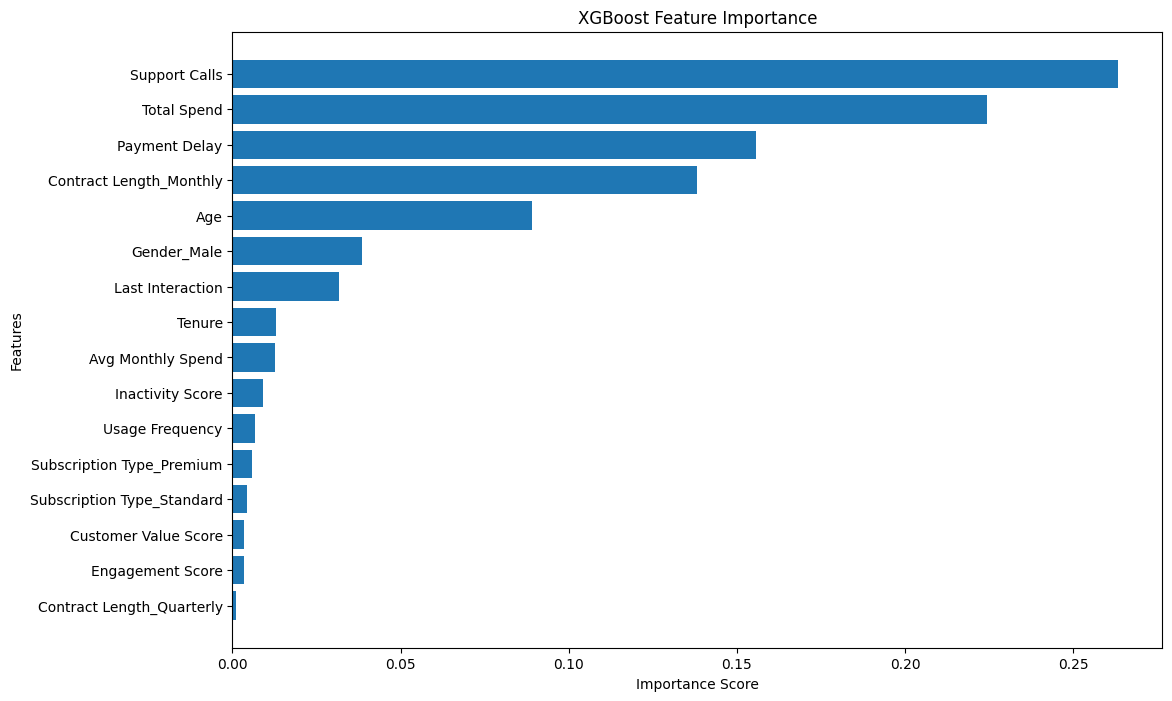

In [100]:
# ============================================================
# FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(12, 8))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance")

plt.gca().invert_yaxis()

plt.show()

ROC CURVE & AUC SCORE

ROC Curve

Shows model discrimination capability.

AUC Score

Measures overall prediction quality.

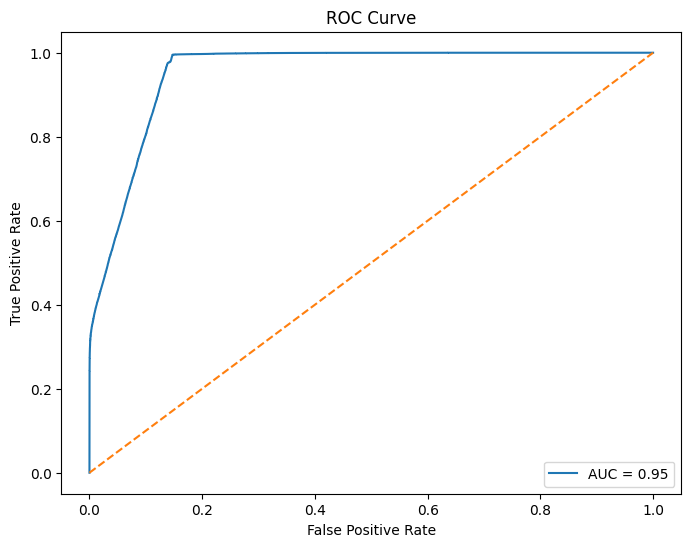


AUC SCORE: 0.9525290997494945


In [101]:
# ============================================================
# ROC CURVE & AUC SCORE
# ============================================================

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label="AUC = %0.2f" % roc_auc
)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

print("\nAUC SCORE:", roc_auc)

CUSTOMER CHURN RISK SEGMENTATION
Groups customers into risk categories.

In [102]:
# ============================================================
# CUSTOMER CHURN RISK SEGMENTATION
# ============================================================

risk_levels = []

for prob in y_prob:

    if prob < 0.30:
        risk_levels.append("Low Risk")

    elif prob < 0.70:
        risk_levels.append("Medium Risk")

    else:
        risk_levels.append("High Risk")

CREATE RESULT DATAFRAME

In [103]:
# ============================================================
# CREATE RESULT DATAFRAME
# ============================================================

results = X_test.copy()

results["Actual Churn"] = y_test.values
results["Predicted Churn"] = y_pred
results["Churn Probability"] = y_prob
results["Risk Level"] = risk_levels

In [104]:
print(results.head())

         Age  Tenure  Usage Frequency  Support Calls  Payment Delay  \
308039  65.0    59.0             11.0            4.0           15.0   
483603  50.0    27.0              9.0            2.0           11.0   
215631  21.0    10.0             25.0            2.0            3.0   
334598  34.0    38.0             23.0            2.0           17.0   
62286   47.0     3.0              3.0            2.0           15.0   

        Total Spend  Last Interaction  Gender_Male  Subscription Type_Premium  \
308039       251.00               7.0        False                       True   
483603       985.79              10.0        False                      False   
215631       734.99              12.0        False                       True   
334598       209.58               2.0         True                      False   
62286        276.00              13.0        False                       True   

        Subscription Type_Standard  Contract Length_Monthly  \
308039                 

PREDICT SAMPLE CUSTOMER

In [105]:
# ============================================================
# SAMPLE CUSTOMER PREDICTION
# ============================================================

sample_customer = pd.DataFrame({

    "Age": [35],
    "Tenure": [15],
    "Usage Frequency": [25],
    "Support Calls": [4],
    "Payment Delay": [2],
    "Total Spend": [1200],
    "Last Interaction": [8],

    "Gender_Male": [1],

    "Subscription Type_Premium": [1],
    "Subscription Type_Standard": [0],

    "Contract Length_Monthly": [1],
    "Contract Length_Quarterly": [0],

    "Avg Monthly Spend": [1200 / 16],

    "Engagement Score": [25 / 9],

    "Customer Value Score": [1200 * 25],

    "Inactivity Score": [8 / 26]

})

ALIGN SAMPLE CUSTOMER COLUMNS

In [106]:
# ============================================================
# ALIGN SAMPLE CUSTOMER COLUMNS
# ============================================================

sample_customer = sample_customer.reindex(
    columns=X_train.columns,
    fill_value=0
)

PREDICT SAMPLE CUSTOMER

In [107]:
# ============================================================
# PREDICT SAMPLE CUSTOMER
# ============================================================

prediction = model.predict(sample_customer)

probability = model.predict_proba(
    sample_customer
)[0][1]

DISPLAY FINAL RESULT

In [108]:
# ============================================================
# DISPLAY FINAL RESULT
# ============================================================

print("\nSAMPLE CUSTOMER PREDICTION\n")

if prediction[0] == 1:
    print("Customer is likely to CHURN")

else:
    print("Customer is likely to STAY")

print("Churn Probability:", probability)


SAMPLE CUSTOMER PREDICTION

Customer is likely to CHURN
Churn Probability: 0.8380182


RETENTION STRATEGY

In [109]:
# ============================================================
# RETENTION STRATEGY
# ============================================================

print("\nRETENTION STRATEGY\n")

if probability > 0.7:

    print("1. Offer special discount")
    print("2. Assign relationship manager")
    print("3. Provide loyalty rewards")

elif probability > 0.4:

    print("1. Send promotional offers")
    print("2. Improve engagement")

else:

    print("Customer is stable")


RETENTION STRATEGY

1. Offer special discount
2. Assign relationship manager
3. Provide loyalty rewards


SAVE RESULTS

In [110]:
# ============================================================
# SAVE RESULTS
# ============================================================

results.to_csv(
    "churn_prediction_results.csv",
    index=False
)

print("\nRESULTS SAVED SUCCESSFULLY")


RESULTS SAVED SUCCESSFULLY
